In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 국내 자동차 제조업 생산활동 시계열 분석

## 분석 목적

본 분석은 KOSIS의 자동차 및 트레일러 제조업 생산능력지수와 가동률지수를 활용하여
2015년부터 2025년까지 국내 자동차 제조업의 생산활동 변화를 분석하는 것을 목적으로 한다.

생산능력의 장기 추세, 가동률의 주요 변동 시점, 월별 패턴 및 계절적 영향을 확인하고,
분석 결과를 바탕으로 자동차 제조업 생산활동의 특징과 로봇자동화 관점의 시사점을 살펴본다.

## 분석 질문

1. 자동차 제조업의 생산능력은 2015~2025년 동안 어떻게 변화했는가?
2. 자동차 제조업의 가동률은 어떤 시기에 크게 상승하거나 하락했는가?
3. 자동차 제조업 가동률에는 반복되는 월별 또는 계절적 패턴이 존재하는가?
4. 계절적 요인을 제거하면 자동차 제조업 가동률의 흐름은 어떻게 달라지는가?

## 데이터 출처

- 출처: KOSIS 국가통계포털
- 조사명: 광업제조업동향조사
- 통계표: 제조업 생산능력 및 가동률지수(2020=100)
- 산업분류: 자동차 및 트레일러 제조업
- 기간: 2015.01 ~ 2025.12
- 주기: 월별

## 1. 분석용 데이터 재구성

원본 KOSIS Excel 파일에서 자동차 및 트레일러 제조업의
생산능력지수, 가동률지수(원지수), 가동률지수(계절조정)를 추출한다.

전체 분석기간은 2015.01 ~ 2026.07이며,
2026년은 7월까지의 부분 연도 데이터이다.

In [2]:
raw_df = pd.read_csv(
    "data/raw/KOSIS_제조업_생산능력_및_가동률지수_원본.csv",
    encoding="cp949"
)

raw_df.head(10)

,산업별,항목,단위,2015.01 월,2015.02 월,2015.03 월,2015.04 월,2015.05 월,2015.06 월,2015.07 월,...,2025.11 월,2025.12 월,2026.01 월,2026.02 월,2026.03 월,2026.04 월,2026.05 월,2026.06 월,2026.07 월,Unnamed: 142
0,제조업,생산능력지수,NaN,94.656,94.656,94.943,94.943,95.038,95.324,95.324,...,105.6,105.7,104.8,104.9,105.3,105.2,105.1,105.5,105.4,NaN
1,제조업,가동률지수(원지수),NaN,104.197,92.865,108.185,107.345,103.358,108.080,106.191,...,101.4,108.7,98.5,91.3,107.9,103.5,99.0,107.5,104.8,NaN
2,제조업,가동률지수(계절조정),NaN,105.605,106.738,104.450,105.380,102.239,104.642,103.183,...,99.7,102.5,99.5,104.6,105.0,103.0,99.6,105.1,105.3,NaN
3,식료품 제조업,생산능력지수,NaN,92.620,92.159,92.066,91.697,91.697,91.513,91.328,...,86.5,86.4,87.1,86.8,87.2,86.7,86.4,86.4,86.4,NaN
4,식료품 제조업,가동률지수(원지수),NaN,101.572,86.640,100.098,100.098,96.169,99.411,100.786,...,113.0,120.5,118.8,99.8,114.6,118.2,111.5,117.2,117.2,NaN
5,식료품 제조업,가동률지수(계절조정),NaN,95.018,99.886,97.737,98.206,97.225,99.135,99.406,...,114.2,115.3,111.5,113.8,113.2,115.4,113.2,120.2,118.6,NaN
6,"도축, 육류 가공 및 저장 처리업",생산능력지수,NaN,86.219,85.788,86.477,85.874,83.463,83.032,82.515,...,76.2,75.1,75.8,73.9,74.3,74.5,73.4,73.8,73.7,NaN
7,"도축, 육류 가공 및 저장 처리업",가동률지수(원지수),NaN,112.257,90.467,94.747,98.541,90.856,94.650,104.280,...,129.8,143.7,146.8,119.0,132.7,143.1,133.7,140.6,147.5,NaN
8,"도축, 육류 가공 및 저장 처리업",가동률지수(계절조정),NaN,101.351,110.315,93.455,99.465,95.194,94.386,97.883,...,139.2,139.4,132.4,141.0,136.4,141.8,138.4,143.7,145.3,NaN
9,수산물 가공 및 저장 처리업,생산능력지수,NaN,92.796,93.270,93.839,93.365,94.502,94.218,95.640,...,75.8,75.6,77.3,78.3,78.2,76.1,75.9,76.0,75.7,NaN


In [3]:
raw_df[
    raw_df["산업별"].astype(str).str.contains("자동차", na=False)
][["산업별", "항목"]]

,산업별,항목
225,자동차 및 트레일러 제조업,생산능력지수
226,자동차 및 트레일러 제조업,가동률지수(원지수)
227,자동차 및 트레일러 제조업,가동률지수(계절조정)
228,자동차용 엔진 및 자동차 제조업,생산능력지수
229,자동차용 엔진 및 자동차 제조업,가동률지수(원지수)
230,자동차용 엔진 및 자동차 제조업,가동률지수(계절조정)
231,자동차 차체 및 트레일러 제조업,생산능력지수
232,자동차 차체 및 트레일러 제조업,가동률지수(원지수)
233,자동차 차체 및 트레일러 제조업,가동률지수(계절조정)
234,자동차 신품 부품 제조업,생산능력지수


In [4]:
target = raw_df[
    raw_df["산업별"].eq("자동차 및 트레일러 제조업")
].copy()

target[["산업별", "항목"]]

,산업별,항목
225,자동차 및 트레일러 제조업,생산능력지수
226,자동차 및 트레일러 제조업,가동률지수(원지수)
227,자동차 및 트레일러 제조업,가동률지수(계절조정)


In [5]:
# 월별 시점 컬럼만 선택
date_cols = [
    col for col in raw_df.columns
    if "월" in str(col)
]

# 3개 지표를 행 → 열 구조로 변환
analysis_df = (
    target
    .set_index("항목")[date_cols]
    .T
    .reset_index()
)

# 컬럼명 정리
analysis_df.columns = [
    "date",
    "production_capacity_index",
    "utilization_index_original",
    "utilization_index_seasonally_adjusted"
]

# 날짜 문자열 정리: "2015.01월" → "2015-01"
analysis_df["date"] = (
    analysis_df["date"]
    .str.replace("월", "", regex=False)
    .str.replace(".", "-", regex=False)
)

analysis_df.head()

,date,production_capacity_index,utilization_index_original,utilization_index_seasonally_adjusted
0,2015-01,96.915,124.696,122.869
1,2015-02,96.816,106.691,126.330
2,2015-03,98.109,132.238,121.129
3,2015-04,98.905,133.820,124.854
4,2015-05,99.104,118.127,119.494


In [6]:
print("데이터 수:", len(analysis_df))
print("시작 시점:", analysis_df["date"].iloc[0])
print("종료 시점:", analysis_df["date"].iloc[-1])

analysis_df.tail()

데이터 수: 139
시작 시점: 2015-01 
종료 시점: 2026-07 


,date,production_capacity_index,utilization_index_original,utilization_index_seasonally_adjusted
134,2026-03,111.4,113.3,107.4
135,2026-04,111.4,106.6,98.5
136,2026-05,111.3,99.7,100.7
137,2026-06,112.1,116.8,113.8
138,2026-07,112.4,106.1,107.3


In [7]:
output_path = "data/automobile_manufacturing_indices_2015_2026.csv"

analysis_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_path)

저장 완료: data/automobile_manufacturing_indices_2015_2026.csv


## 2. 데이터 기본 정보 및 품질 검증

분석에 앞서 분석용 데이터의 구조와 자료형을 확인하고,
분석 기간, 결측치, 중복 시점 및 월별 데이터 누락 여부를 검증한다.

In [8]:
df = pd.read_csv(
    "data/automobile_manufacturing_indices_2015_2026.csv"
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 4 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   date                                   139 non-null    str    
 1   production_capacity_index              139 non-null    float64
 2   utilization_index_original             139 non-null    float64
 3   utilization_index_seasonally_adjusted  139 non-null    float64
dtypes: float64(3), str(1)
memory usage: 4.5 KB


In [9]:
# date 컬럼이 문자열일 때만 공백 제거 후 datetime 형식으로 변환
if not pd.api.types.is_datetime64_any_dtype(df["date"]):
    df["date"] = df["date"].str.strip()
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m")

print("시작 시점:", df["date"].min())
print("종료 시점:", df["date"].max())
print("전체 데이터 수:", len(df))

시작 시점: 2015-01-01 00:00:00
종료 시점: 2026-07-01 00:00:00
전체 데이터 수: 139


In [10]:
# 컬럼별 결측치 확인
df.isna().sum()

date                                     0
production_capacity_index                0
utilization_index_original               0
utilization_index_seasonally_adjusted    0
dtype: int64

In [11]:
# 동일한 월이 중복되어 있는지 확인
duplicate_count = df["date"].duplicated().sum()

print("중복 시점 수:", duplicate_count)

중복 시점 수: 0


In [12]:
# 전체 분석기간에 누락된 월이 있는지 확인
expected_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="MS"
)

missing_dates = expected_dates.difference(df["date"])

print("예상 월 수:", len(expected_dates))
print("실제 월 수:", len(df))
print("누락 월 수:", len(missing_dates))
print("누락 월:", missing_dates.tolist())

예상 월 수: 139
실제 월 수: 139
누락 월 수: 0
누락 월: []


### 이상치 처리 기준

본 분석에서는 급격한 상승·하락 값을 통계적 기준만으로 이상치로 판단하여 제거하지 않았다.

자동차 및 트레일러 제조업의 생산능력 및 가동률 변동은 실제 생산활동의 변화일 가능성이 있으며, 특히 가동률의 급격한 변동 시점은 본 분석의 주요 분석 대상이기 때문이다.

따라서 원자료의 값을 임의로 제거하거나 보정하지 않고 그대로 사용하였으며, 전월 대비 변화율과 연도별 표준편차 등을 활용하여 변동이 큰 시점을 별도로 확인하였다.

또한 급격한 변동의 구체적인 원인은 본 데이터만으로 단정하지 않고, 원인 해석에는 추가 자료가 필요하다는 점을 분석 결과에 명시하였다.

## 3. 생산능력지수 장기 추세 분석

### Q1. 자동차 및 트레일러 제조업의 생산능력은 2015년부터 2026년 7월까지 어떻게 변화했는가?

월별 생산능력지수의 단기 변동을 완화하고 장기적인 변화 추세를 확인하기 위해 12개월 이동평균을 적용한다.

- 분석 지표: 생산능력지수
- 분석 기간: 2015.01 ~ 2026.07
- 분석 방법: 전체 시계열 추이 및 12개월 이동평균
- 참고: 2026년 데이터는 1월부터 7월까지만 포함된 부분 연도 데이터이다.

In [13]:
# 생산능력지수의 12개월 이동평균 계산
df["capacity_ma12"] = (
    df["production_capacity_index"]
    .rolling(window=12)
    .mean()
)

df[
    ["date", "production_capacity_index", "capacity_ma12"]
].head(15)

,date,production_capacity_index,capacity_ma12
0,2015-01-01,96.915,NaN
1,2015-02-01,96.816,NaN
2,2015-03-01,98.109,NaN
3,2015-04-01,98.905,NaN
4,2015-05-01,99.104,NaN
5,2015-06-01,99.701,NaN
6,2015-07-01,99.900,NaN
7,2015-08-01,100.000,NaN
8,2015-09-01,100.199,NaN
9,2015-10-01,101.095,NaN


In [14]:
# Matplotlib 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

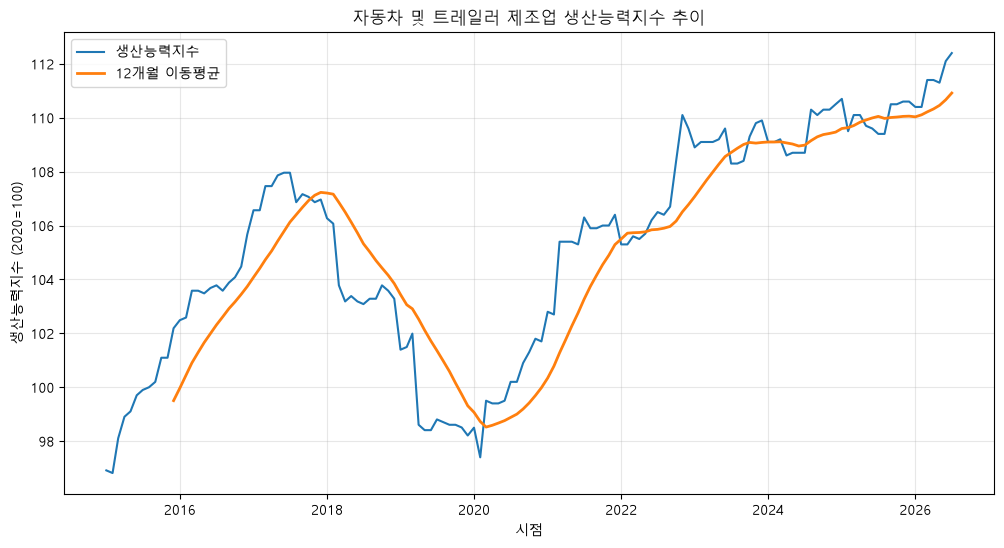

In [15]:
# 생산능력지수와 12개월 이동평균 시각화
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["production_capacity_index"],
    label="생산능력지수"
)

plt.plot(
    df["date"],
    df["capacity_ma12"],
    label="12개월 이동평균",
    linewidth=2
)

plt.title("자동차 및 트레일러 제조업 생산능력지수 추이")
plt.xlabel("시점")
plt.ylabel("생산능력지수 (2020=100)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/01_production_capacity_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# 생산능력지수의 최저점과 최고점 확인
min_idx = df["production_capacity_index"].idxmin()
max_idx = df["production_capacity_index"].idxmax()

print("생산능력지수 최저점")
print("시점:", df.loc[min_idx, "date"].strftime("%Y-%m"))
print("지수:", df.loc[min_idx, "production_capacity_index"])

print()

print("생산능력지수 최고점")
print("시점:", df.loc[max_idx, "date"].strftime("%Y-%m"))
print("지수:", df.loc[max_idx, "production_capacity_index"])

생산능력지수 최저점
시점: 2015-02
지수: 96.816

생산능력지수 최고점
시점: 2026-07
지수: 112.4


In [17]:
# 분석 시작 시점과 최신 시점의 생산능력지수 비교
start_value = df.iloc[0]["production_capacity_index"]
latest_value = df.iloc[-1]["production_capacity_index"]

change = latest_value - start_value
change_rate = (latest_value / start_value - 1) * 100

print("2015-01 생산능력지수:", start_value)
print("2026-07 생산능력지수:", latest_value)
print("지수 변화:", round(change, 3))
print("변화율:", round(change_rate, 2), "%")

2015-01 생산능력지수: 96.915
2026-07 생산능력지수: 112.4
지수 변화: 15.485
변화율: 15.98 %


In [18]:
# 연도별 평균 생산능력지수 계산
yearly_capacity = (
    df.assign(year=df["date"].dt.year)
    .groupby("year")["production_capacity_index"]
    .mean()
    .round(3)
)

yearly_capacity

year
2015     99.502
2016    103.740
2017    107.231
2018    103.848
2019     99.312
2020     99.983
2021    105.292
2022    106.775
2023    109.083
2024    109.467
2025    110.058
2026    111.343
Name: production_capacity_index, dtype: float64

In [19]:
# 2025년과 2026년의 동일 기간(1~7월) 생산능력지수 비교
jan_jul = df[
    (df["date"].dt.month <= 7) &
    (df["date"].dt.year.isin([2025, 2026]))
]

jan_jul_avg = (
    jan_jul
    .assign(year=jan_jul["date"].dt.year)
    .groupby("year")["production_capacity_index"]
    .mean()
)

change_rate_2026 = (
    (jan_jul_avg.loc[2026] / jan_jul_avg.loc[2025]) - 1
) * 100

print("2025년 1~7월 평균:", round(jan_jul_avg.loc[2025], 3))
print("2026년 1~7월 평균:", round(jan_jul_avg.loc[2026], 3))
print("동일 기간 변화율:", round(change_rate_2026, 2), "%")

2025년 1~7월 평균: 109.871
2026년 1~7월 평균: 111.343
동일 기간 변화율: 1.34 %


### Q1 분석 결과

생산능력지수와 12개월 이동평균을 분석한 결과, 자동차 및 트레일러 제조업의 생산능력은 전체 기간에 걸쳐 단순히 지속 상승한 것이 아니라 **상승, 하락, 회복을 거친 후 최근 높은 수준을 나타냈다.**

- 2015년 1월 생산능력지수는 **96.915**였으며, 2026년 7월에는 **112.4**로 상승하였다. 두 시점 간 지수는 **15.485포인트**, 약 **15.98% 증가**하였다.
- 연평균 생산능력지수는 2015년 **99.502**에서 2017년 **107.231**까지 상승한 뒤, 2018년 **103.848**, 2019년 **99.312**로 하락하였다.
- 이후 2021년 **105.292**, 2023년 **109.083**, 2025년 **110.058**로 다시 상승하면서 장기적인 회복 및 상승 흐름이 나타났다.
- 월별 생산능력지수의 최저치는 **2015년 2월 96.816**, 최고치는 **2026년 7월 112.4**로 확인되었다.
- 12개월 이동평균에서도 2018~2020년의 하락 이후 다시 상승하는 흐름이 나타났으며, 최근에는 분석기간 중 높은 수준을 유지하고 있음을 확인할 수 있다.
- 2026년 자료는 7월까지의 부분 연도이므로 2025년 연평균과 직접 비교하지 않았다. 동일 기간을 비교한 결과, 2025년 1~7월 평균은 **109.871**, 2026년 1~7월 평균은 **111.343**으로 약 **1.34% 상승**하였다.

따라서 자동차 및 트레일러 제조업의 생산능력은 분석기간 중 중간 하락 구간이 존재했으나, **장기적으로는 확대되는 흐름을 보였으며 최근 생산능력 수준은 분석기간 초보다 높은 것으로 나타났다.**

> **해석 시 주의:** 2026년 데이터는 1~7월까지만 존재하는 부분 연도이므로 연간 평균을 이전의 완결 연도와 직접 비교하지 않았다. 또한 생산능력지수의 변화만으로 특정 원인이나 로봇자동화 투자의 영향을 직접 설명할 수는 없다. 원인 분석을 위해서는 설비투자, 생산량, 수요 및 자동화 관련 데이터 등 추가 자료가 필요하다.

## Q2. 자동차 및 트레일러 제조업의 가동률은 어떤 시기에 크게 상승하거나 하락했는가?

월별 가동률의 주요 변동 시점을 확인하기 위해 계절적 요인이 조정된 **가동률지수(계절조정)**를 사용하여 전월 대비 변화율을 분석한다.

- 분석 지표: 가동률지수(계절조정)
- 분석 기간: 2015.01 ~ 2026.07
- 분석 방법: 전월 대비 증감률 계산 및 주요 급등·급락 시점 확인
- 참고: 원지수는 계절적 영향을 포함하므로 단기적인 월별 변동 시점 분석에는 계절조정지수를 사용한다.

In [20]:
# 계절조정 가동률지수의 전월 대비 변화율 계산
df["utilization_change_pct"] = (
    df["utilization_index_seasonally_adjusted"]
    .pct_change()
    * 100
)

# 전월 대비 상승률이 가장 큰 5개 시점
top_increases = (
    df[["date", "utilization_index_seasonally_adjusted", "utilization_change_pct"]]
    .nlargest(5, "utilization_change_pct")
)

# 전월 대비 하락률이 가장 큰 5개 시점
top_decreases = (
    df[["date", "utilization_index_seasonally_adjusted", "utilization_change_pct"]]
    .nsmallest(5, "utilization_change_pct")
)

print("가동률지수 전월 대비 주요 상승 시점")
display(top_increases)

print("가동률지수 전월 대비 주요 하락 시점")
display(top_decreases)

가동률지수 전월 대비 주요 상승 시점


,date,utilization_index_seasonally_adjusted,utilization_change_pct
62,2020-03-01,109.5,41.290323
65,2020-06-01,90.9,21.361816
127,2025-08-01,116.6,20.082389
66,2020-07-01,107.4,18.151815
68,2020-09-01,115.0,15.927419


가동률지수 전월 대비 주요 하락 시점


,date,utilization_index_seasonally_adjusted,utilization_change_pct
61,2020-02-01,77.500,-27.637722
64,2020-05-01,74.900,-22.543950
19,2016-08-01,93.632,-18.844800
35,2017-12-01,88.099,-17.924520
128,2025-09-01,99.400,-14.751286


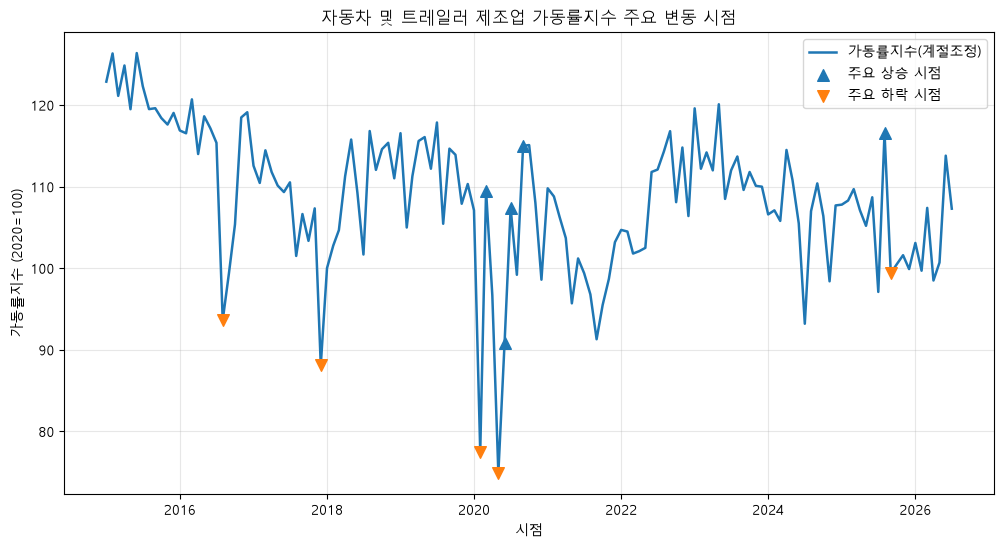

In [21]:
# 계절조정 가동률지수와 주요 급등·급락 시점 시각화

plt.figure(figsize=(12, 6))

# 전체 가동률지수
plt.plot(
    df["date"],
    df["utilization_index_seasonally_adjusted"],
    label="가동률지수(계절조정)",
    linewidth=1.8
)

# 주요 상승 시점
plt.scatter(
    top_increases["date"],
    top_increases["utilization_index_seasonally_adjusted"],
    marker="^",
    s=70,
    label="주요 상승 시점",
    zorder=3
)

# 주요 하락 시점
plt.scatter(
    top_decreases["date"],
    top_decreases["utilization_index_seasonally_adjusted"],
    marker="v",
    s=70,
    label="주요 하락 시점",
    zorder=3
)

plt.title("자동차 및 트레일러 제조업 가동률지수 주요 변동 시점")
plt.xlabel("시점")
plt.ylabel("가동률지수 (2020=100)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/02_utilization_major_changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# 연도별 가동률지수 변동성 계산
# 표준편차가 클수록 해당 연도 내 월별 가동률 변동이 컸다는 의미

yearly_volatility = (
    df.assign(year=df["date"].dt.year)
    .groupby("year")["utilization_index_seasonally_adjusted"]
    .std()
    .round(3)
    .sort_values(ascending=False)
)

print("연도별 가동률지수 변동성 (표준편차)")
yearly_volatility

연도별 가동률지수 변동성 (표준편차)


year
2020    13.297
2016     8.677
2017     7.069
2018     5.916
2021     5.691
2025     5.599
2024     5.576
2026     5.447
2022     5.415
2019     4.337
2023     3.678
2015     3.063
Name: utilization_index_seasonally_adjusted, dtype: float64

### Q2 분석 결과

계절적 영향을 제거한 가동률지수(계절조정)의 전월 대비 변화율과 연도별 표준편차를 분석한 결과, 자동차 및 트레일러 제조업의 가동률은 전체 기간에 걸쳐 상당한 월별 변동을 보였으며, 특히 **2020년에 가장 큰 변동성이 나타났다.**

- 전월 대비 가장 큰 상승은 **2020년 3월**로, 계절조정 가동률지수가 109.5를 기록하며 전월 대비 약 **41.29% 상승**하였다.
- 그 밖의 주요 상승 시점은 **2020년 6월(+21.36%)**, **2025년 8월(+20.08%)**, **2020년 7월(+18.15%)**, **2020년 9월(+15.93%)**로 나타났다.
- 전월 대비 가장 큰 하락은 **2020년 2월**로, 계절조정 가동률지수가 77.5를 기록하며 전월 대비 약 **27.64% 하락**하였다.
- 그 밖의 주요 하락 시점은 **2020년 5월(-22.54%)**, **2016년 8월(-18.84%)**, **2017년 12월(-17.92%)**, **2025년 9월(-14.75%)**로 나타났다.
- 특히 2020년은 주요 상승 시점과 하락 시점이 반복적으로 나타났으며, 연도별 가동률지수의 표준편차도 **13.297**로 분석기간 중 가장 높았다. 이는 2016년 **8.677**, 2017년 **7.069**보다도 높은 수준으로, 2020년에 월별 가동률 변동이 특히 컸음을 보여준다.
- 2025년에도 8월 **+20.08%** 상승 후 9월 **-14.75%** 하락하는 등 단기간에 큰 폭의 변동이 나타났다.

따라서 자동차 및 트레일러 제조업의 가동률은 일정한 수준으로 움직이기보다 시기별로 큰 변동을 보였으며, **특히 2020년은 분석기간 중 가동률 변동성이 가장 두드러진 시기로 확인되었다.**

> **해석 시 주의:** 본 분석은 계절조정 가동률지수의 통계적 변동을 확인한 것으로, 특정 시점의 급등·급락 원인을 직접 설명하지 않는다. 경기 변화, 생산 차질, 수요 변화, 공급망 문제 등 구체적인 원인을 판단하기 위해서는 별도의 관련 자료가 필요하다. 또한 2026년은 1~7월까지만 존재하는 부분 연도이므로 연도별 변동성 수치를 완결 연도와 동일한 조건으로 직접 비교하는 데 주의가 필요하다.

## Q3. 자동차 및 트레일러 제조업의 가동률에는 반복되는 월별 또는 계절적 패턴이 존재하는가?

가동률에 특정 월마다 반복되는 패턴이 존재하는지 확인하기 위해 계절적 영향을 포함하고 있는 **가동률지수(원지수)**의 월별 평균을 비교한다.

- 분석 지표: 가동률지수(원지수)
- 계절성 분석 기간: 2015.01 ~ 2025.12
- 분석 방법: 월별 가동률지수 평균 비교
- 2026년 제외 이유: 2026년은 1~7월까지만 존재하는 부분 연도이므로 월별 평균 비교에서 제외한다.
- 참고: 계절성을 확인하는 것이 목적이므로 계절적 요인이 제거된 계절조정지수가 아닌 원지수를 사용한다.

In [23]:
# Q3 계절성 분석용 데이터
# 2026년은 부분 연도이므로 제외하고 2015~2025년만 사용

seasonal_df = df[
    (df["date"].dt.year >= 2015) &
    (df["date"].dt.year <= 2025)
].copy()

# 월 정보 추가
seasonal_df["month"] = seasonal_df["date"].dt.month

# 월별 가동률지수(원지수) 평균 계산
monthly_utilization = (
    seasonal_df
    .groupby("month")["utilization_index_original"]
    .mean()
    .round(3)
)

print("2015~2025년 월별 평균 가동률지수(원지수)")
monthly_utilization

2015~2025년 월별 평균 가동률지수(원지수)


month
1     104.848
2      97.372
3     119.156
4     115.869
5     109.346
6     112.859
7     110.590
8      93.789
9     101.810
10    109.120
11    115.828
12    113.875
Name: utilization_index_original, dtype: float64

In [24]:
# 월별 평균 가동률지수 최고/최저 월 확인

max_month = monthly_utilization.idxmax()
max_value = monthly_utilization.max()

min_month = monthly_utilization.idxmin()
min_value = monthly_utilization.min()

print("월별 평균 가동률지수 최고")
print("월:", max_month)
print("지수:", max_value)

print()

print("월별 평균 가동률지수 최저")
print("월:", min_month)
print("지수:", min_value)

print()

print("최고-최저 차이:", round(max_value - min_value, 3))

월별 평균 가동률지수 최고
월: 3
지수: 119.156

월별 평균 가동률지수 최저
월: 8
지수: 93.789

최고-최저 차이: 25.367


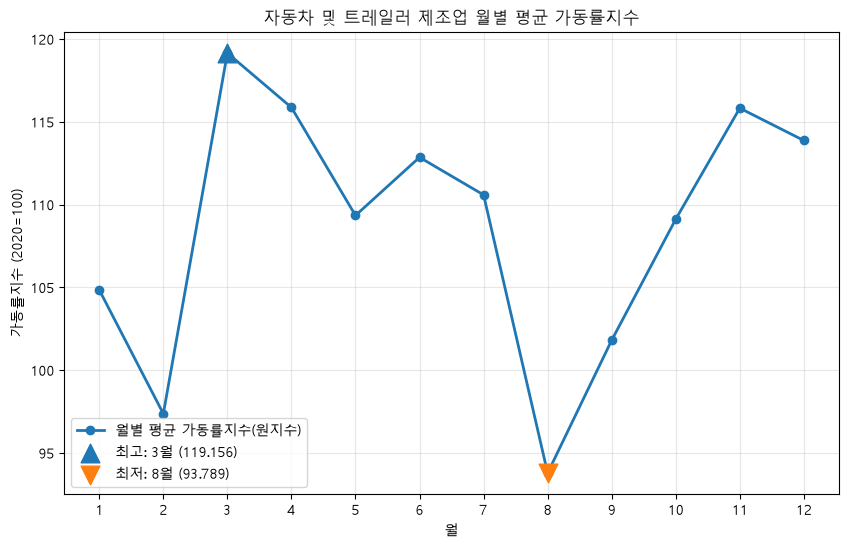

In [25]:
# 월별 평균 가동률지수 시각화

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_utilization.index,
    monthly_utilization.values,
    marker="o",
    linewidth=2,
    label="월별 평균 가동률지수(원지수)"
)

# 최고 / 최저 월 강조
plt.scatter(
    max_month,
    max_value,
    s=180,
    marker="^",
    zorder=5,
    label=f"최고: {max_month}월 ({max_value:.3f})"
)

plt.scatter(
    min_month,
    min_value,
    s=180,
    marker="v",
    zorder=5,
    label=f"최저: {min_month}월 ({min_value:.3f})"
)

plt.title("자동차 및 트레일러 제조업 월별 평균 가동률지수")
plt.xlabel("월")
plt.ylabel("가동률지수 (2020=100)")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/03_monthly_utilization_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Q3 분석 결과

2015년부터 2025년까지의 완결 연도 데이터를 기준으로 가동률지수(원지수)의 월별 평균을 비교한 결과, 월별로 일정한 수준 차이가 나타났으며 일부 월에서는 반복적으로 높은 또는 낮은 가동률이 관찰되었다.

- 월별 평균 가동률지수가 가장 높은 달은 **3월**로, 평균 지수는 **119.156**이었다.
- 가장 낮은 달은 **8월**로, 평균 지수는 **93.789**였다.
- 최고 월과 최저 월의 평균 가동률지수 차이는 **25.367포인트**로 나타났다.
- 3월과 4월은 각각 **119.156**, **115.869**로 비교적 높은 수준을 보였으며, 11월과 12월도 각각 **115.828**, **113.875**로 높은 편이었다.
- 반면 2월은 **97.372**, 8월은 **93.789**로 상대적으로 낮은 수준을 나타냈다.
- 특히 7월 평균 110.590에서 8월 93.789로 크게 낮아진 뒤, 9월 101.810, 10월 109.120, 11월 115.828로 다시 상승하는 흐름이 관찰되었다.

따라서 자동차 및 트레일러 제조업의 가동률에는 월별로 일정한 차이가 존재하며, **봄철과 연말에는 상대적으로 높은 수준, 일부 여름철에는 낮은 수준이 나타나는 패턴**이 확인되었다.

> **해석 시 주의:** 본 결과는 2015~2025년의 월별 평균을 비교한 것으로, 월별 평균 차이만으로 계절성이 통계적으로 확정되었다고 단정할 수는 없다. 또한 월별 가동률 차이의 원인을 직접 설명하기 위해서는 휴가, 조업일수, 생산계획, 수요 변화 등 추가 자료가 필요하다. 2026년은 1~7월까지만 존재하는 부분 연도이므로 월별 평균 비교에서 제외하였다.

## Q4. 계절적 요인을 제거하면 자동차 제조업 가동률의 흐름은 어떻게 달라지는가?

가동률지수 원지수와 계절조정지수를 비교하여 계절적 요인이 월별 가동률 변동에 미치는 영향을 확인한다.

- 분석 지표: 가동률지수(원지수), 가동률지수(계절조정)
- 분석 기간: 2015.01 ~ 2026.07
- 분석 방법: 두 지수의 시계열 비교 및 차이 분석
- 참고: 계절조정지수는 반복적인 계절적 영향을 조정한 지표이므로 원지수와 비교하여 기초적인 흐름을 확인한다.

In [26]:
# 원지수와 계절조정지수의 차이 계산
df["seasonal_gap"] = (
    df["utilization_index_original"]
    - df["utilization_index_seasonally_adjusted"]
)

# 차이가 가장 큰 시점 확인
largest_gaps = (
    df[
        [
            "date",
            "utilization_index_original",
            "utilization_index_seasonally_adjusted",
            "seasonal_gap"
        ]
    ]
    .assign(abs_gap=lambda x: x["seasonal_gap"].abs())
    .nlargest(10, "abs_gap")
)

largest_gaps

,date,utilization_index_original,utilization_index_seasonally_adjusted,seasonal_gap,abs_gap
7,2015-08-01,96.107,119.506,-23.399,23.399
1,2015-02-01,106.691,126.330,-19.639,19.639
120,2025-01-01,89.900,107.800,-17.900,17.900
67,2020-08-01,82.200,99.200,-17.000,17.000
96,2023-01-01,103.000,119.600,-16.600,16.600
73,2021-02-01,92.600,108.800,-16.200,16.200
37,2018-02-01,87.226,102.779,-15.553,15.553
133,2026-02-01,84.200,99.700,-15.500,15.500
49,2019-02-01,89.659,104.994,-15.335,15.335
127,2025-08-01,101.900,116.600,-14.700,14.700


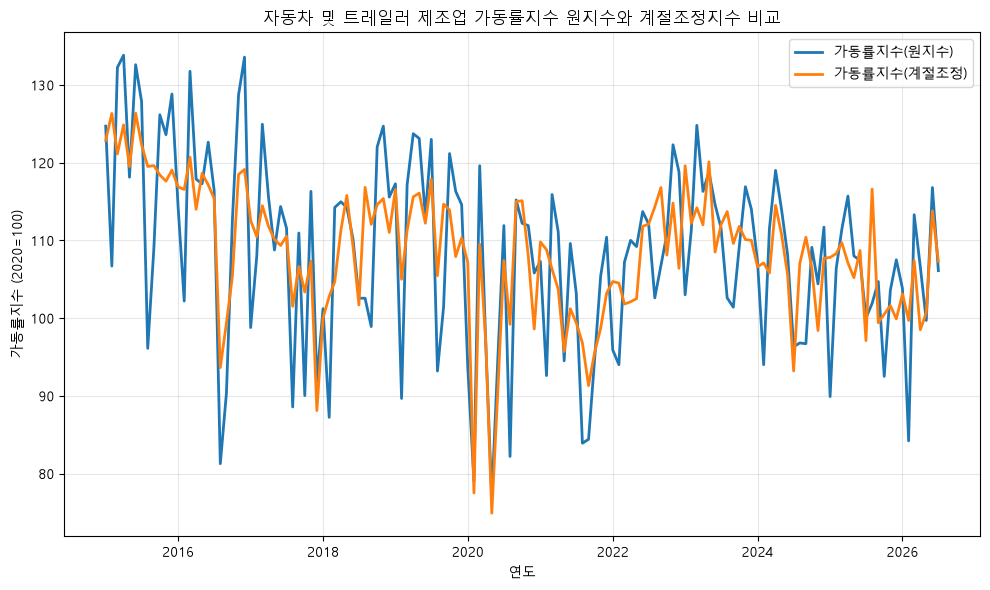

In [27]:
# 가동률지수 원지수와 계절조정지수 비교

plt.figure(figsize=(10, 6))

plt.plot(
    df["date"],
    df["utilization_index_original"],
    linewidth=2,
    label="가동률지수(원지수)"
)

plt.plot(
    df["date"],
    df["utilization_index_seasonally_adjusted"],
    linewidth=2,
    label="가동률지수(계절조정)"
)

plt.title("자동차 및 트레일러 제조업 가동률지수 원지수와 계절조정지수 비교")
plt.xlabel("연도")
plt.ylabel("가동률지수 (2020=100)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "images/04_original_vs_seasonally_adjusted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Q4 분석 결과

가동률지수 원지수와 계절조정지수를 비교한 결과, 두 지수의 전반적인 흐름은 유사하지만 일부 시점에서는 상당한 차이가 나타났다. 계절조정지수는 원지수에서 반복적인 계절적 영향을 조정하기 때문에 원지수에 나타나는 월별 변동이 일부 완화되어 나타났다.

- 원지수와 계절조정지수의 절대 차이가 가장 크게 나타난 시점은 **2015년 8월**로, 원지수는 **96.107**, 계절조정지수는 **119.506**이었으며 차이는 **-23.399포인트**였다.
- **2015년 2월**에도 원지수 106.691, 계절조정지수 126.330으로 **-19.639포인트**의 큰 차이가 나타났다.
- **2025년 1월**은 -17.900포인트, **2020년 8월**은 -17.000포인트의 차이를 보였다.
- 절대 차이가 큰 상위 시점에는 **2월과 8월이 반복적으로 포함**되었다. 이는 Q3에서 2월과 8월의 월별 평균 원지수가 상대적으로 낮게 나타난 결과와도 방향이 일치한다.
- 특히 절대 차이가 큰 상위 10개 시점에서는 모두 원지수가 계절조정지수보다 낮게 나타났다. 이는 해당 시점들의 낮은 원지수에 반복적인 계절적 요인이 포함되어 있음을 보여준다.
- 계절조정지수에서도 장·단기적인 상승과 하락 자체는 남아 있으므로, 모든 가동률 변동이 계절적 요인만으로 발생하는 것은 아니다.

따라서 자동차 및 트레일러 제조업의 가동률은 계절적 요인의 영향을 받으며, 특히 일부 월의 원지수 하락에는 반복적인 계절 패턴이 포함되어 있는 것으로 나타났다. 계절조정지수를 활용하면 이러한 계절적 영향을 완화하여 가동률의 기초적인 흐름을 보다 명확하게 확인할 수 있다.

> **해석 시 주의:** 계절조정지수는 계절적 영향을 조정한 통계지표이지만, 원지수와의 차이만으로 휴가, 조업일수, 명절, 수요 변화 등 특정 원인을 직접 확정할 수는 없다. 구체적인 원인 분석에는 추가 자료가 필요하다.